# Step 5: コードをわかりやすく整えよう。

- 5-1. 関数を導入する前に : 構造化の必要性
- 5-2. 関数の基本
- 5-3. ここまで作成したコードを関数化してみる
- 5-4. main関数の活用

## ✅ 関数を導入する前に : 構造化の必要性

### ✔︎ ここまででできるようになったこと
<div style="background-color:#eef; padding:10px;">
これまでの講義で、次のことができるようになった。

- open-meteo API からデータを取得する
- CSV として保存・読み込みができる
- pandas を使って必要なデータを抽出できる
- 平均値を計算し、図として可視化できる

ここまで実施してきたことを並べて書いてみると、以下のコード群になる。
</dv>

Saved: tokyo_daily_mean_temperature_1980_2025.csv


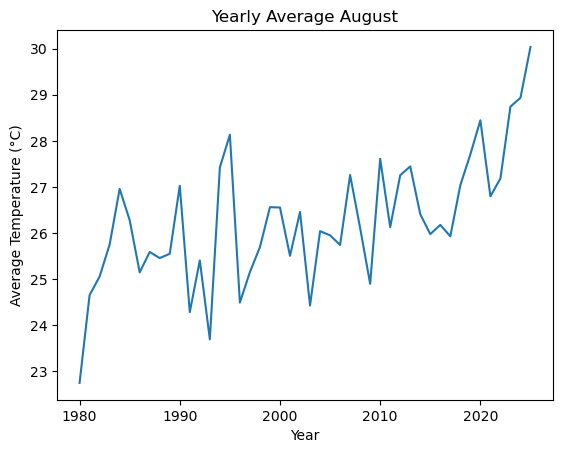

In [28]:
# ==============================
# 1. パッケージの読み込み
# ==============================
import requests
import pandas as pd
import csv
import matplotlib.pyplot as plt

# ==============================
# 2. open-metao APIからのデータ取得
# ==============================


# 2-1. API用のパラメータ準備

lat = 35.6895
lon = 139.6917
params = {
    "latitude": lat,
    "longitude": lon,
    "start_date": "1980-08-01",
    "end_date": "2025-08-31",
    "daily": "temperature_2m_mean",
    "timezone": "Asia/Tokyo"
}

# 2-2. データ取得
url = "https://archive-api.open-meteo.com/v1/archive"
r = requests.get(url, params=params, timeout=60)
r.raise_for_status()
data = r.json()

# ==============================
# 3. JSONデータの保存
# ==============================

df = pd.DataFrame({
    "date": data["daily"]["time"],
    "tmean_C": data["daily"]["temperature_2m_mean"]
})
# CSV 出力
out_file = "tokyo_daily_mean_temperature_1980_2025.csv"
df.to_csv(out_file, index=False, encoding="utf-8-sig")

print(f"Saved: {out_file}")

# ==============================
# 4. CSV読み込み
# ==============================

# CSV入力
dates = []
temps = []

with open("tokyo_daily_mean_temperature_1980_2025.csv", "r", encoding="utf-8") as f:
    reader = csv.reader(f)
    header = next(reader)  # 列名を読み飛ばす

    for row in reader:
        date = row[0]   # 例: "1980-08-01"
        temp = row[1]
        dates.append(date)
        temps.append(float(temp))

# データフレームの作成
df = pd.DataFrame({
    "date": dates,
    "temp": temps
})

# ==============================
# 5. データ前処理
# ==============================

# 5-1. 日付の処理
df["date"] = pd.to_datetime(df["date"])

# 5-2. 8月データ抽出
df = df[(df["date"].dt.month == 8)]

# 5-3. 年ごとの平均の計算
df["year"] = df["date"].dt.year
years = range(1980, 2026)
year_means = []

for y in years:
    mean_temp = df[df["year"] == y]["temp"]
    year_means.append(sum(mean_temp)/len(mean_temp))

dfAugust = pd.DataFrame({
    "year": years,
    "ave_temp": year_means
})

# ==============================
# 6. 図の作成
# ==============================
plt.plot(dfAugust["year"], dfAugust["ave_temp"])
plt.xlabel("Year")
plt.ylabel("Average Temperature (°C)")
plt.title("Yearly Average August")
plt.show()

### ✔︎ 長いコードの問題点
<div style="background-color:#eef; padding:10px;">    
現状では、コードはまだ数十行程度に収まっている。しかし、処理が複雑になればなるほど、コードの行数は増え、全体の見通しは次第に難しくなっていく。

例えば、次のような追加解析を考えてみよう。

- 都市を東京からニューヨークに変更したらどうなるか
- 対象とする月を 8 月から 7 月に変更したらどうなるか

こうした解析を行うたびに、既存のコードをコピー＆ペーストして実行する、という方法をとると、その分だけコードの行数は増えていく。解析の数が増えるにつれて、コードは次第にかさ増しされ、最終的には、作成者である自分自身ですら、このコードが「何のために存在しているのか」を即座に把握することが難しくなる。

この問題は、コードが間違っているから生じるのではない。むしろ、解析を正しく拡張していく過程で、必然的に発生する問題である。

そこで必要になるのが、「処理にかたまりをもたせてプログラムを設計する」という考え方である。処理を適切な単位に分割し、それぞれに役割を持たせることで、プログラム全体の構造を把握しやすくすることができる。

この考え方は、本における「目次」に例えることができる。目次を見ることで、どこに何が書かれているかが一目で分かり、必要な箇所をすぐに参照できるのと同様に、プログラムにおいても処理の構造が明確であれば、全体の理解や修正が容易になる。

この「処理のかたまり化」を実現するための基本的な仕組みが 関数（function） である。
次章では、関数とは何か、そしてどのように用いるのかについて詳しく説明する。
</dv>

## ✅ 関数の基本

### 関数とは？
<div style="background-color:#eef; padding:10px;">
関数とは、「ある処理をまとめて名前をつけたもの」である。

---

```python
def 関数名(引数):
    処理
    return 戻り値
```

---

```python
def 関数名(引数1, 引数2, ...):
    処理
    return 戻り値1, 戻り値2, ...
```

---

引数は「関数の中で使う変数」であり、戻り値とは「関数の実行結果として返される値」である。
引数や戻り値は指定しない場合もある。
引数を複数設定する場合はカンマで区切って指定する。

関数の例：

---

```python
def say_hello():
    print("Hello")
```

---

```python
def add(a, b):
    return a + b
```

---

```python
# dataリストから平均と標準偏差を計算し、返す
def calc_mean_std(data):
    mean = sum(data) / len(data)
    std = (sum((x - mean)**2 for x in data) / len(data))**0.5
    return mean, std
```

---

</div>

In [25]:
# 実際に入力してみる

### 関数の使用時の注意
<div style="background-color:#eef; padding:10px;">

- 関数は、呼び出す前に定義されている必要がある。
　Python は上から下へ順番にコードを実行するため、まだ定義されていない関数を呼び出すことはできない。

- 関数の中と外では、変数は別物として扱われる。
　関数内で定義された変数は、その関数の中でのみ有効であり、関数の外から直接参照することはできない。

- 関数内で使われた変数は、関数の処理が終了すると基本的に不要になる。
（内部的には、関数の実行が終わるとその変数は参照されなくなり、Python によって適切に管理される。）

関数の中と外の変数が別物であることを確認するために、次のコードを実行してみよう:

---

```python
def add(a, b):
    a = a + b
    return a

a = 3
b = 5

tmp = add(a,b)
print(tmp)
print(a)

```
↓↓↓
```text
13
3
```

---

関数 add の中で使われている a は、関数に渡された値をもとに作られた別の変数である。
このため、関数内で a の値を変更しても、関数の外にある a の値は変化しない。
関数はあくまでも「関数は、外部から値を受け取り、結果を返す独立した処理単位」であり、
上手に活用することで予期せぬ挙動を減らすことができる。

</div>

In [23]:
# 実際に入力してみる

## ✅ ここまで作成したコードを関数化してみる

<div style="background-color:#eef; padding:10px;">

- 先のコードはコメントアウト位置で役割を分割していた。その役割ごとに関数化してみよう。
- なお、実務上非常に重要なのが、「関数化は一気に行わず、1つずつ導入して挙動を調べる」ことである。これによって、関数に問題があった場合、どの関数で問題が生じたかを特定しやすくなる。

---

2. open-metao APIからのデータ取得

```python

# start = "1980-08-01"
# end = "2025-08-31"
# を新たに定義する必要があることに注意。

def fetch_temperature_data(lat, lon, start, end):
    params = {
        "latitude": lat,
        "longitude": lon,
        "start_date": start,
        "end_date": end,
        "daily": "temperature_2m_mean",
        "timezone": "Asia/Tokyo"
    }
    url = "https://archive-api.open-meteo.com/v1/archive"
    r = requests.get(url, params=params, timeout=60)
    r.raise_for_status()
    data = r.json()
    return data
```

---

3. JSON -> CSVデータの保存

```python

def save_temperature_csv(data, out_file):
    df = pd.DataFrame({
        "date": data["daily"]["time"],
        "temp": data["daily"]["temperature_2m_mean"]
    })
    df.to_csv(out_file, index=False, encoding="utf-8-sig")
    print(f"Saved: {out_file}")
```

---

4. CSV → DataFrame

```python

# pathに呼び出しファイルのパスを入力する。
def load_temperature_csv(path):
    df = pd.read_csv(path)
    df["date"] = pd.to_datetime(df["date"])
    return df

```

---

5. データ前処理

```python

# month = 8
def calc_month_mean(df,month):
    df_month = df[df["date"].dt.month == month]
    years = range(1980, 2026)
    df_month["year"] = df_month["date"].dt.year
    year_means = []
    for y in years:
        mean_temp = df_month[df_month["year"] == y]["temp"]
        year_means.append(sum(mean_temp)/len(mean_temp))
    df_month_selected = pd.DataFrame({
        "year": years,
        "ave_temp": year_means
    })
    return df_month_selected

```

---

6. 可視化

```python
def plot_august_temperature(df):
    plt.plot(df["year"], df["ave_temp"])
    plt.xlabel("Year")
    plt.ylabel("Average Temperature (°C)")
    plt.title("Yearly Average August Temperature")
    plt.show()

```
---

</div>

Saved: tokyo_daily_mean_temperature_1980_2025.csv


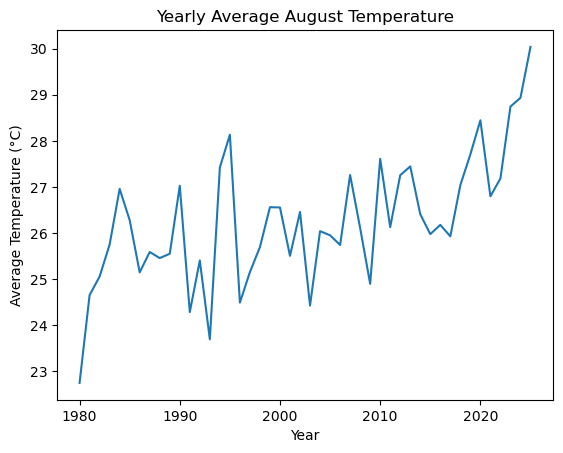

In [40]:
# 以下のコードを徐々に関数化してみよう。

# ==============================
# 1. パッケージの読み込み
# ==============================
import requests
import pandas as pd
import csv
import matplotlib.pyplot as plt

# ==============================
# 2. open-metao APIからのデータ取得
# ==============================


# 2-1. API用のパラメータ準備

lat = 35.6895
lon = 139.6917
params = {
    "latitude": lat,
    "longitude": lon,
    "start_date": "1980-08-01",
    "end_date": "2025-08-31",
    "daily": "temperature_2m_mean",
    "timezone": "Asia/Tokyo"
}

# 2-2. データ取得
url = "https://archive-api.open-meteo.com/v1/archive"
r = requests.get(url, params=params, timeout=60)
r.raise_for_status()
data = r.json()

# ==============================
# 3. JSONデータの保存
# ==============================

df = pd.DataFrame({
    "date": data["daily"]["time"],
    "tmean_C": data["daily"]["temperature_2m_mean"]
})
# CSV 出力
out_file = "tokyo_daily_mean_temperature_1980_2025.csv"
df.to_csv(out_file, index=False, encoding="utf-8-sig")

print(f"Saved: {out_file}")

# ==============================
# 4. CSV読み込み
# ==============================

# CSV入力
dates = []
temps = []

with open("tokyo_daily_mean_temperature_1980_2025.csv", "r", encoding="utf-8") as f:
    reader = csv.reader(f)
    header = next(reader)  # 列名を読み飛ばす

    for row in reader:
        date = row[0]   # 例: "1980-08-01"
        temp = row[1]
        dates.append(date)
        temps.append(float(temp))

# データフレームの作成
df = pd.DataFrame({
    "date": dates,
    "temp": temps
})

# ==============================
# 5. データ前処理
# ==============================

# 5-1. 日付の処理
df["date"] = pd.to_datetime(df["date"])

# 5-2. 8月データ抽出
df = df[(df["date"].dt.month == 8)]

# 5-3. 年ごとの平均の計算
df["year"] = df["date"].dt.year
years = range(1980, 2026)
year_means = []

for y in years:
    mean_temp = df[df["year"] == y]["temp"]
    year_means.append(sum(mean_temp)/len(mean_temp))

dfAugust = pd.DataFrame({
    "year": years,
    "ave_temp": year_means
})

# ==============================
# 6. 図の作成
# ==============================
plt.plot(dfAugust["year"], dfAugust["ave_temp"])
plt.xlabel("Year")
plt.ylabel("Average Temperature (°C)")
plt.title("Yearly Average August")
plt.show()

<div style="background-color:#eef; padding:10px;">    
完成系は以下のようになり、処理部分の行数を5行程度におさめることができる。
</dv>

In [ ]:
# ==============================
# パッケージの読み込み
# ==============================
import requests
import pandas as pd
import csv
import matplotlib.pyplot as plt

# ==============================
# 関数
# ==============================

def fetch_temperature_data(lat, lon, start, end):
    params = {
        "latitude": lat,
        "longitude": lon,
        "start_date": start,
        "end_date": end,
        "daily": "temperature_2m_mean",
        "timezone": "Asia/Tokyo"
    }
    url = "https://archive-api.open-meteo.com/v1/archive"
    r = requests.get(url, params=params, timeout=60)
    r.raise_for_status()
    data = r.json()
    return data

def save_temperature_csv(data, out_file):
    df = pd.DataFrame({
        "date": data["daily"]["time"],
        "temp": data["daily"]["temperature_2m_mean"]
    })
    df.to_csv(out_file, index=False, encoding="utf-8-sig")
    print(f"Saved: {out_file}")

def load_temperature_csv(path):
    df = pd.read_csv(path)
    df["date"] = pd.to_datetime(df["date"])
    return df

def calc_month_mean(df,month):
    df_month = df[df["date"].dt.month == month]
    years = range(1980, 2026)
    df_month["year"] = df_month["date"].dt.year
    year_means = []
    for y in years:
        mean_temp = df_month[df_month["year"] == y]["temp"]
        year_means.append(sum(mean_temp)/len(mean_temp))
    df_month_selected = pd.DataFrame({
        "year": years,
        "ave_temp": year_means
    })
    return df_month_selected

def plot_august_temperature(df):
    plt.plot(df["year"], df["ave_temp"])
    plt.xlabel("Year")
    plt.ylabel("Average Temperature (°C)")
    plt.title("Yearly Average August Temperature")
    plt.show()

# ==============================
# パラメタ
# ==============================

# API用のパラメータ準備
lat = 35.6895
lon = 139.6917
start = "1980-08-01"
end = "2025-08-31"

# CSV 出力先 / 入力元
out_file = "tokyo_daily_mean_temperature_1980_2025.csv"

# CSV 出力先 / 入力元
month = 8

# ==============================
# 処理
# ==============================

# open-metao APIからのデータ取得
data = fetch_temperature_data(lat, lon, start, end)

# JSON -> CSVデータの保存
save_temperature_csv(data, out_file)

# CSV読み込み
df = load_temperature_csv(out_file)

# データ前処理
dfAugust = calc_month_mean(df,month)

# 図の作成
plot_august_temperature(dfAugust)

## ✅ main関数の活用

<div style="background-color:#eef; padding:10px;">

ここまでのコードでは、処理の内容は関数として整理されているが、実際にプログラムを動かしている処理はファイルの下部にそのまま書かれている。
この処理部分を main 関数 としてまとめておくことで、コードの可読性をさらに向上させることができる。

---

```python
def main():
    data = fetch_temperature_data(lat, lon, start, end)
    save_temperature_csv(data, out_file)
    df = load_temperature_csv(out_file)
    dfAugust = calc_month_mean(df,month)
    plot_august_temperature(dfAugust)
```

---

main 関数には、「このプログラムが何をするのか」という処理の流れだけを書く。
個々の処理の詳細は、すでに定義した関数の中に隠されているため、main 関数を読むだけで解析全体の流れを把握することができる。

main 関数のご利益は、単に処理をまとめることではなく、「mainと関数を分けることができる」点である。
main 関数を導入することで、ファイルを以下のように分割し、解析の全体設計を更にわかりやすくすることができる。

---

```text
temperature_project/
├─ analysis.py      ← main だけ
├─ functions.py     ← 関数だけ
└─ data/

```

---


Python では、同じ .py ファイルであっても、使われ方には大きく分けて2通りがある。

1. プログラムとして直接実行される場合
2. 他のファイルから読み込まれる場合（import）

今回の構成では、analysis.py が 1 の役割を担い、functions.py は 2 の役割を担っている。

Python では、直接実行されるファイルと、import によって読み込まれるファイルとを区別するために、次の記述を用いる。

```python
if __name__ == "__main__":
    main()
```

この記述により、

- analysis.py が 直接実行されたときのみ main() が実行される
- import analysis によって読み込まれた場合には、解析処理が自動的に実行されない

という振る舞いを実現している。

その結果、analysis.py は
「直接実行もできるし、Notebook などから analysis.main() を明示的に呼び出して実行することもできる」
という安全で柔軟な設計になっている。

---
functions.py

```python
# ==============================
# functions.py
# ==============================

import requests
import pandas as pd
import matplotlib.pyplot as plt


def fetch_temperature_data(lat, lon, start, end):
    """
    open-meteo API から日平均気温データを取得する
    """
    params = {
        "latitude": lat,
        "longitude": lon,
        "start_date": start,
        "end_date": end,
        "daily": "temperature_2m_mean",
        "timezone": "Asia/Tokyo"
    }
    url = "https://archive-api.open-meteo.com/v1/archive"

    r = requests.get(url, params=params, timeout=60)
    r.raise_for_status()

    return r.json()


def save_temperature_csv(data, out_file):
    """
    API で取得した JSON データを CSV として保存する
    """
    df = pd.DataFrame({
        "date": data["daily"]["time"],
        "temp": data["daily"]["temperature_2m_mean"]
    })

    df.to_csv(out_file, index=False, encoding="utf-8-sig")
    print(f"Saved: {out_file}")


def load_temperature_csv(path):
    """
    CSV ファイルを読み込み、DataFrame として返す
    """
    df = pd.read_csv(path)
    df["date"] = pd.to_datetime(df["date"])
    return df


def calc_month_mean(df, month):
    """
    指定した月の年平均気温を計算する
    """
    df_month = df[df["date"].dt.month == month].copy()
    df_month["year"] = df_month["date"].dt.year

    years = sorted(df_month["year"].unique())
    year_means = []

    for y in years:
        temps = df_month[df_month["year"] == y]["temp"]
        year_means.append(temps.mean())

    return pd.DataFrame({
        "year": years,
        "ave_temp": year_means
    })


def plot_month_temperature(df, month):
    """
    月平均気温の経年変化をプロットする
    """
    plt.plot(df["year"], df["ave_temp"])
    plt.xlabel("Year")
    plt.ylabel("Average Temperature (°C)")
    plt.title(f"Yearly Average Temperature (Month = {month})")
    plt.grid(True)
    plt.show()
```
---
---
analysis.py

```python
# ==============================
# analysis.py
# ==============================

from functions import (
    fetch_temperature_data,
    save_temperature_csv,
    load_temperature_csv,
    calc_month_mean,
    plot_month_temperature
)


def main():
    # ==============================
    # パラメータ設定
    # ==============================

    # 東京
    lat = 35.6895
    lon = 139.6917

    # 解析期間
    start = "1980-08-01"
    end = "2025-08-31"

    # 対象月
    month = 8

    # CSV ファイル
    out_file = "tokyo_daily_mean_temperature_1980_2025.csv"

    # ==============================
    # 処理の流れ
    # ==============================

    # データ取得
    data = fetch_temperature_data(lat, lon, start, end)

    # JSON → CSV
    save_temperature_csv(data, out_file)

    # CSV → DataFrame
    df = load_temperature_csv(out_file)

    # 月平均の計算
    df_month = calc_month_mean(df, month)

    # 可視化
    plot_month_temperature(df_month, month)


if __name__ == "__main__":
    main()

```




</div>

<div style="background-color:#eef; padding:10px;">
temperature_projectに移動し、実際にanalysis.main()を実行してみよう。
（analysis.pyを別のフォルダ位置から実行することもできるが、同じ位置で実行するのが堅実な運用方法であるため、初学者にはこのやり方を推奨）
</div>

In [42]:
cd temperature_project

/Volumes/WorkEnv/work/tools/myrepos/tuat-python-seminar-2025/notebooks/Python_Programming_Basics/temperature_project


Saved: tokyo_daily_mean_temperature_1980_2025.csv


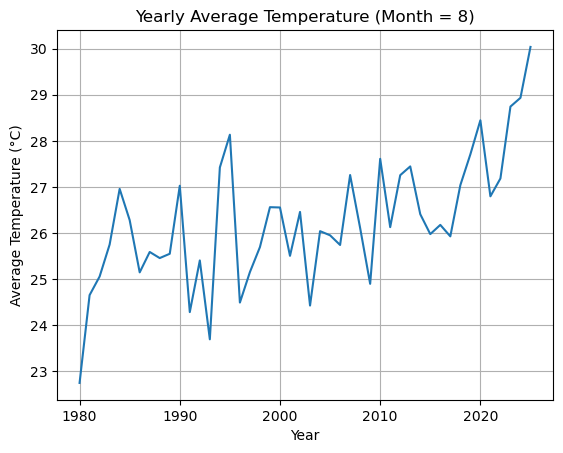

In [43]:
import analysis
analysis.main()

# Step 5の練習問題

1. 数値 x を受け取り、その2乗を返す関数を作成せよ。

2. 数値のリストを受け取り、平均値と最大値を同時に返す関数を作成せよ。

3. analysis.py の対象月を 12 に変更し、東京の12月の月平均気温の年変化を可視化せよ。

4. 東京とニューヨークの緯度経度情報が以下のように与えられている時、

   cities = {
    "Tokyo": (35.6895, 139.6917),
    "NewYork": (40.7128, -74.0060)
    }


   "Tokyo"の緯度経度情報は以下のようにして取得することができる:

```python
    lat, lon = cities["NewYork"]
```

    都市名の文字列を引数とし、緯度経度情報を戻り値として返すget_city_location(city)関数を作成せよ。

5. 3で作成したget_city_location(city)関数を用い、"NewYork"の1980年から2025年までの8月の平均気温を可視化せよ。

6. "Tokyo" と "NewYork" の1980年から2025年までの8月の平均気温を上下に表示できるように main() を整理せよ。

7. "Tokyo" と "NewYork" の1980年から2025年までの8月の平均気温の前年差分を上下に表示できるように main() を整理せよ。